# Guia practica: globo de medicion de variables meteorologicas

Este notebook implementa una aplicacion numerica real para el oscilador amortiguado que modela el movimiento vertical de un globo cerca de su nivel de equilibrio o de boyancia neutra. Se compara el esquema derivado con diferencias centrales y hacia adelante frente al metodo de Euler hacia adelante y frente a la solucion analitica, y al final se incluye una animacion del globo oscilando alrededor del equilibrio.

## Ecuacion del problema

Se resuelve la ecuacion

$$m\,\ddot y = -\beta\,\dot y - \gamma\,y,$$

o, equivalentemente,

$$m\,\ddot y + \beta\,\dot y + \gamma\,y = 0.$$

El caso base del inciso usa las condiciones iniciales

$$y(0)=0, \qquad y'(0)=v_0.$$

La discretizacion principal usada en el notebook es

$$y_{n+1} = \frac{2m + \beta h - \gamma h^2}{m + \beta h} y_n - \frac{m}{m + \beta h} y_{n-1},$$

iniciando con un paso de Taylor de segundo orden para construir `y_1`. Como `y(0)=0`, el arranque del caso base queda `y_1 = v_0 h - (\beta v_0 / 2m) h^2`.

## Derivacion compacta del esquema

Usando

$$\ddot y(t_n) \approx \frac{y_{n+1}-2y_n+y_{n-1}}{h^2}, \qquad \dot y(t_n) \approx \frac{y_{n+1}-y_n}{h},$$

en

$$m\,\ddot y = -\beta\,\dot y - \gamma\,y,$$

se obtiene

$$m\frac{y_{n+1}-2y_n+y_{n-1}}{h^2} + \beta\frac{y_{n+1}-y_n}{h} + \gamma y_n = 0.$$

Multiplicando por `h^2` y despejando `y_{n+1}`:

$$(m+\beta h)y_{n+1} = (2m+\beta h-\gamma h^2)y_n - m y_{n-1},$$

$$y_{n+1} = \frac{2m+\beta h-\gamma h^2}{m+\beta h} y_n - \frac{m}{m+\beta h} y_{n-1}.$$

Como el metodo es de dos pasos, se inicia con `y_0 = 0` y `y_1 = v_0 h - (\beta v_0 / 2m) h^2`. Esta es la formula que luego se implementa y compara con el metodo de Euler hacia adelante.

In [1]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np
import pandas as pd
from IPython.display import Image, display

plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.5f}'.format

BASE_DIR = Path.cwd().resolve().parents[0]
OUTPUT_DIR = BASE_DIR / 'content' / 'files_globo_medicion'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_PATH = OUTPUT_DIR / 'resumen_globo_medicion.json'


def system_characteristics(m, beta, gamma):
    omega_0 = math.sqrt(gamma / m)
    alpha = beta / (2.0 * m)
    discriminant = alpha**2 - omega_0**2
    if math.isclose(discriminant, 0.0, abs_tol=1e-12):
        regime = 'critico'
    elif discriminant < 0:
        regime = 'subamortiguado'
    else:
        regime = 'sobreamortiguado'
    return {'omega_0': omega_0, 'alpha': alpha, 'discriminant': discriminant, 'regime': regime}


def exact_solution(times, m, beta, gamma, y0, v0):
    props = system_characteristics(m, beta, gamma)
    alpha = props['alpha']
    omega_0 = props['omega_0']
    regime = props['regime']

    if regime == 'subamortiguado':
        omega_d = math.sqrt(omega_0**2 - alpha**2)
        c1 = y0
        c2 = (v0 + alpha * y0) / omega_d
        exp_term = np.exp(-alpha * times)
        cos_term = np.cos(omega_d * times)
        sin_term = np.sin(omega_d * times)
        y = exp_term * (c1 * cos_term + c2 * sin_term)
        v = exp_term * (
            -alpha * (c1 * cos_term + c2 * sin_term)
            + (-c1 * omega_d * sin_term + c2 * omega_d * cos_term)
        )
    elif regime == 'critico':
        c1 = y0
        c2 = v0 + alpha * y0
        exp_term = np.exp(-alpha * times)
        y = exp_term * (c1 + c2 * times)
        v = exp_term * (c2 - alpha * (c1 + c2 * times))
    else:
        root = math.sqrt(alpha**2 - omega_0**2)
        r1 = -alpha + root
        r2 = -alpha - root
        c1 = (v0 - r2 * y0) / (r1 - r2)
        c2 = y0 - c1
        exp1 = np.exp(r1 * times)
        exp2 = np.exp(r2 * times)
        y = c1 * exp1 + c2 * exp2
        v = c1 * r1 * exp1 + c2 * r2 * exp2
    return y, v, props


def central_forward_stepper(m, beta, gamma, y0, v0, dt, t_end, start_method='taylor'):
    times = np.arange(0.0, t_end + dt, dt)
    y = np.zeros_like(times)
    y[0] = y0
    a0 = -(beta * v0 + gamma * y0) / m
    if len(times) > 1:
        if start_method == 'euler':
            y[1] = y0 + v0 * dt
        elif start_method == 'exact':
            y_exact_start, _, _ = exact_solution(np.array([0.0, dt]), m, beta, gamma, y0, v0)
            y[1] = y_exact_start[1]
        else:
            y[1] = y0 + v0 * dt + 0.5 * a0 * dt**2
    coeff_1 = (2.0 * m + beta * dt - gamma * dt**2) / (m + beta * dt)
    coeff_2 = m / (m + beta * dt)
    for n in range(1, len(times) - 1):
        y[n + 1] = coeff_1 * y[n] - coeff_2 * y[n - 1]

    v = np.zeros_like(times)
    if len(times) > 1:
        v[0] = v0
        for n in range(1, len(times) - 1):
            v[n] = (y[n + 1] - y[n - 1]) / (2.0 * dt)
        v[-1] = (y[-1] - y[-2]) / dt

    return times, y, v


def euler_forward_stepper(m, beta, gamma, y0, v0, dt, t_end):
    times = np.arange(0.0, t_end + dt, dt)
    y = np.zeros_like(times)
    v = np.zeros_like(times)
    y[0] = y0
    v[0] = v0
    for n in range(len(times) - 1):
        y[n + 1] = y[n] + dt * v[n]
        v[n + 1] = v[n] + dt * (-(beta * v[n] + gamma * y[n]) / m)
    return times, y, v


def compute_metrics(reference, approximation):
    error = approximation - reference
    return {
        'rmse': float(np.sqrt(np.mean(error**2))),
        'mae': float(np.mean(np.abs(error))),
        'e2': float(np.sqrt(np.mean(error**2))),
        'einf': float(np.max(np.abs(error))),
        'max_abs_error': float(np.max(np.abs(error))),
        'final_error': float(error[-1]),
    }


def discrete_energy(m, k, y, v):
    return 0.5 * m * v**2 + 0.5 * k * y**2


def zero_crossings(y):
    signs = np.sign(y)
    return int(np.sum(signs[:-1] * signs[1:] < 0))


def settling_time(times, y, tolerance=0.05):
    threshold = tolerance * np.max(np.abs(y))
    for idx in range(len(y)):
        if np.all(np.abs(y[idx:]) <= threshold):
            return float(times[idx])
    return float(times[-1])


def apparent_period(times, y):
    sign_changes = np.where(np.sign(y[:-1]) * np.sign(y[1:]) < 0)[0]
    if len(sign_changes) < 3:
        return np.nan
    crossing_times = times[sign_changes]
    half_periods = np.diff(crossing_times)
    if len(half_periods) == 0:
        return np.nan
    return float(2.0 * np.mean(half_periods))


def make_case_dict(name, m, beta, gamma, y0, v0, dt, t_end, start_method='taylor'):
    times = np.arange(0.0, t_end + dt, dt)
    y_exact, v_exact, props = exact_solution(times, m, beta, gamma, y0, v0)
    _, y_scheme, v_scheme = central_forward_stepper(m, beta, gamma, y0, v0, dt, t_end, start_method=start_method)
    _, y_euler, v_euler = euler_forward_stepper(m, beta, gamma, y0, v0, dt, t_end)
    return {
        'name': name,
        'm': m,
        'beta': beta,
        'gamma': gamma,
        'y0': y0,
        'v0': v0,
        'dt': dt,
        't_end': t_end,
        'regime': props['regime'],
        'times': times,
        'y_exact': y_exact,
        'v_exact': v_exact,
        'y_scheme': y_scheme,
        'v_scheme': v_scheme,
        'y_euler': y_euler,
        'v_euler': v_euler,
    }


def summarize_response(case):
    return {
        'regimen': case['regime'],
        'desplazamiento_maximo': float(np.max(np.abs(case['y_scheme']))),
        'periodo_aparente': apparent_period(case['times'], case['y_scheme']),
        'cruces_cero': zero_crossings(case['y_scheme']),
        'tiempo_estabilizacion_5pct': settling_time(case['times'], case['y_scheme'], tolerance=0.05),
    }


def summarize_case(case):
    y_exact, v_exact, props = exact_solution(
        case['times'], case['m'], case['beta'], case['gamma'], case['y0'], case['v0']
    )
    return {
        'regimen': props['regime'],
        'omega_0': props['omega_0'],
        'alpha': props['alpha'],
        'desplazamiento_inicial': float(case['y0']),
        'desplazamiento_final_exacto': float(y_exact[-1]),
        'desplazamiento_final_esquema': float(case['y_scheme'][-1]),
        'desplazamiento_final_euler': float(case['y_euler'][-1]),
        'rmse_esquema': compute_metrics(y_exact, case['y_scheme'])['rmse'],
        'rmse_euler': compute_metrics(y_exact, case['y_euler'])['rmse'],
    }


def make_displacement_plot(main_case):
    fig, ax = plt.subplots(figsize=(11, 5.2))
    ax.plot(main_case['times'], main_case['y_exact'], color='#0f172a', lw=2.2, label='Solucion analitica')
    ax.plot(main_case['times'], main_case['y_scheme'], color='#0f766e', lw=1.6, ls='--', label='Esquema centrado-adelante')
    ax.plot(main_case['times'], main_case['y_euler'], color='#b45309', lw=1.2, alpha=0.9, label='Metodo de Euler hacia adelante')
    ax.axhline(0.0, color='#64748b', lw=0.9)
    ax.set_title('Comparacion temporal para el caso base del inciso')
    ax.set_xlabel('Tiempo')
    ax.set_ylabel('Desplazamiento vertical y(t)')
    ax.legend(frameon=False)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    path = OUTPUT_DIR / 'globo_desplazamiento_comparacion.png'
    fig.savefig(path, dpi=180)
    plt.close(fig)
    return path


def make_phase_plot(main_case):
    fig, ax = plt.subplots(figsize=(6.4, 6.0))
    ax.plot(main_case['y_exact'], main_case['v_exact'], color='#0f172a', lw=2.0, label='Solucion analitica')
    ax.plot(main_case['y_scheme'], main_case['v_scheme'], color='#0f766e', lw=1.5, ls='--', label='Esquema centrado-adelante')
    ax.plot(main_case['y_euler'], main_case['v_euler'], color='#b45309', lw=1.0, alpha=0.9, label='Metodo de Euler hacia adelante')
    ax.set_title('Retrato de fase del globo')
    ax.set_xlabel('y')
    ax.set_ylabel('v = dy/dt')
    ax.legend(frameon=False)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    path = OUTPUT_DIR / 'globo_retrato_fase.png'
    fig.savefig(path, dpi=180)
    plt.close(fig)
    return path


def make_regimes_plot(cases):
    fig, axes = plt.subplots(3, 1, figsize=(10.5, 10.0), sharex=True)
    colors = {
        'subamortiguado': '#0f766e',
        'critico': '#1d4ed8',
        'sobreamortiguado': '#b91c1c',
    }
    for ax, case in zip(axes, cases):
        ax.plot(case['times'], case['y_exact'], color='#111827', lw=2.0, label='Analitica')
        ax.plot(case['times'], case['y_scheme'], color=colors[case['regime']], lw=1.5, ls='--', label='Esquema')
        ax.set_title(f"Caso {case['name']}: beta = {case['beta']}")
        ax.set_ylabel('y(t)')
        ax.grid(alpha=0.25)
        ax.legend(frameon=False, ncol=2)
    axes[-1].set_xlabel('Tiempo')
    fig.tight_layout()
    path = OUTPUT_DIR / 'globo_regimenes_amortiguamiento.png'
    fig.savefig(path, dpi=180)
    plt.close(fig)
    return path


def make_convergence_plot(study_rows):
    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    ax.loglog(study_rows['dt'], study_rows['rmse_esquema'], marker='o', color='#0f766e', lw=1.8, label='Esquema centrado-adelante')
    ax.loglog(study_rows['dt'], study_rows['rmse_euler'], marker='s', color='#b45309', lw=1.5, label='Metodo de Euler hacia adelante')
    ax.invert_xaxis()
    ax.set_title('Sensibilidad del error al paso temporal')
    ax.set_xlabel('Paso temporal h')
    ax.set_ylabel('RMSE frente a la solucion analitica')
    ax.legend(frameon=False)
    ax.grid(alpha=0.25, which='both')
    fig.tight_layout()
    path = OUTPUT_DIR / 'globo_convergencia_dt.png'
    fig.savefig(path, dpi=180)
    plt.close(fig)
    return path


def make_energy_plot(main_case):
    energy_exact = discrete_energy(main_case['m'], main_case['gamma'], main_case['y_exact'], main_case['v_exact'])
    energy_scheme = discrete_energy(main_case['m'], main_case['gamma'], main_case['y_scheme'], main_case['v_scheme'])
    energy_euler = discrete_energy(main_case['m'], main_case['gamma'], main_case['y_euler'], main_case['v_euler'])
    fig, ax = plt.subplots(figsize=(10.5, 4.8))
    ax.plot(main_case['times'], energy_exact, color='#0f172a', lw=2.0, label='Analitica')
    ax.plot(main_case['times'], energy_scheme, color='#0f766e', lw=1.5, ls='--', label='Esquema')
    ax.plot(main_case['times'], energy_euler, color='#b45309', lw=1.2, alpha=0.9, label='Euler')
    ax.set_title('Decaimiento de energia mecanica del sistema')
    ax.set_xlabel('Tiempo')
    ax.set_ylabel('Energia')
    ax.legend(frameon=False)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    path = OUTPUT_DIR / 'globo_energia.png'
    fig.savefig(path, dpi=180)
    plt.close(fig)
    return path


def make_beta_sensitivity_plot(beta_cases):
    fig, ax = plt.subplots(figsize=(10.5, 5.4))
    for case in beta_cases:
        ax.plot(
            case['times'],
            case['y_scheme'],
            lw=1.8,
            label=f"beta={case['beta']:.2f} ({case['regime']})",
        )
    ax.axhline(0.0, color='#64748b', lw=0.9)
    ax.set_title('Sensibilidad fisica a beta')
    ax.set_xlabel('Tiempo')
    ax.set_ylabel('y(t)')
    ax.legend(frameon=False, ncol=2)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    path = OUTPUT_DIR / 'globo_sensibilidad_beta.png'
    fig.savefig(path, dpi=180)
    plt.close(fig)
    return path


def make_gamma_mass_sensitivity_plot(period_grid, gamma_values, mass_values):
    fig, ax = plt.subplots(figsize=(8.2, 5.8))
    im = ax.imshow(period_grid, origin='lower', cmap='YlGnBu', aspect='auto')
    ax.set_xticks(np.arange(len(gamma_values)), labels=[f'{value:.2f}' for value in gamma_values])
    ax.set_yticks(np.arange(len(mass_values)), labels=[f'{value:.2f}' for value in mass_values])
    ax.set_xlabel('gamma')
    ax.set_ylabel('m')
    ax.set_title('Periodo aparente segun gamma y m')
    for i in range(len(mass_values)):
        for j in range(len(gamma_values)):
            val = period_grid[i, j]
            ax.text(j, i, f'{val:.2f}' if np.isfinite(val) else '-', ha='center', va='center', color='#111827', fontsize=9)
    fig.colorbar(im, ax=ax, label='Periodo aparente')
    fig.tight_layout()
    path = OUTPUT_DIR / 'globo_sensibilidad_gamma_m.png'
    fig.savefig(path, dpi=180)
    plt.close(fig)
    return path


def make_initial_condition_sensitivity_plot(v0_cases, y0_cases):
    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), sharey=True)
    for case in v0_cases:
        axes[0].plot(case['times'], case['y_scheme'], lw=1.7, label=f"v0={case['v0']:.2f}")
    axes[0].axhline(0.0, color='#64748b', lw=0.9)
    axes[0].set_title('Sensibilidad a la velocidad inicial')
    axes[0].set_xlabel('Tiempo')
    axes[0].set_ylabel('y(t)')
    axes[0].legend(frameon=False)
    axes[0].grid(alpha=0.25)

    for case in y0_cases:
        axes[1].plot(case['times'], case['y_scheme'], lw=1.7, label=f"y0={case['y0']:.2f}")
    axes[1].axhline(0.0, color='#64748b', lw=0.9)
    axes[1].set_title('Sensibilidad al desplazamiento inicial')
    axes[1].set_xlabel('Tiempo')
    axes[1].legend(frameon=False)
    axes[1].grid(alpha=0.25)
    fig.tight_layout()
    path = OUTPUT_DIR / 'globo_sensibilidad_condiciones_iniciales.png'
    fig.savefig(path, dpi=180)
    plt.close(fig)
    return path


def make_convergence_norms_plot(norms_df):
    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))
    axes[0].loglog(norms_df['dt'], norms_df['einf_esquema'], marker='o', color='#0f766e', lw=1.8, label='Einf esquema')
    axes[0].loglog(norms_df['dt'], norms_df['e2_esquema'], marker='s', color='#1d4ed8', lw=1.6, label='E2 esquema')
    axes[0].invert_xaxis()
    axes[0].set_title('Normas de error del esquema derivado')
    axes[0].set_xlabel('Paso temporal h')
    axes[0].set_ylabel('Error')
    axes[0].legend(frameon=False)
    axes[0].grid(alpha=0.25, which='both')

    axes[1].semilogx(norms_df['dt'], norms_df['ratio_einf'], marker='o', color='#b45309', lw=1.8, label='Razon Einf')
    axes[1].semilogx(norms_df['dt'], norms_df['ratio_e2'], marker='s', color='#7c3aed', lw=1.6, label='Razon E2')
    axes[1].invert_xaxis()
    axes[1].axhline(2.0, color='#64748b', lw=0.9, ls='--')
    axes[1].set_title('Razon de convergencia al refinar h')
    axes[1].set_xlabel('Paso temporal h')
    axes[1].set_ylabel('Razon E(h) / E(h/2)')
    axes[1].legend(frameon=False)
    axes[1].grid(alpha=0.25)
    fig.tight_layout()
    path = OUTPUT_DIR / 'globo_convergencia_normas.png'
    fig.savefig(path, dpi=180)
    plt.close(fig)
    return path


def make_stability_plot(dt_cases):
    fig, ax = plt.subplots(figsize=(10.8, 5.4))
    for case in dt_cases:
        ax.plot(case['times'], case['y_scheme'], lw=1.5, label=f"h={case['dt']:.2f}")
    ax.axhline(0.0, color='#64748b', lw=0.9)
    ax.set_title('Sensibilidad de estabilidad al paso temporal')
    ax.set_xlabel('Tiempo')
    ax.set_ylabel('y(t)')
    ax.legend(frameon=False, ncol=3)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    path = OUTPUT_DIR / 'globo_estabilidad_dt.png'
    fig.savefig(path, dpi=180)
    plt.close(fig)
    return path


def make_start_method_plot(start_cases):
    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))
    for label, case in start_cases.items():
        axes[0].plot(case['times'], case['y_scheme'], lw=1.7, label=label)
    exact_case = start_cases['Exacto']
    axes[0].plot(exact_case['times'], exact_case['y_exact'], color='#111827', lw=2.2, label='Solucion analitica')
    axes[0].axhline(0.0, color='#64748b', lw=0.9)
    axes[0].set_title('Respuesta segun metodo de arranque')
    axes[0].set_xlabel('Tiempo')
    axes[0].set_ylabel('y(t)')
    axes[0].legend(frameon=False)
    axes[0].grid(alpha=0.25)

    start_labels = list(start_cases.keys())
    errs = [compute_metrics(case['y_exact'], case['y_scheme'])['einf'] for case in start_cases.values()]
    axes[1].bar(start_labels, errs, color=['#b45309', '#0f766e', '#1d4ed8'])
    axes[1].set_title('Error maximo segun arranque')
    axes[1].set_ylabel('Einf')
    axes[1].grid(alpha=0.25, axis='y')
    fig.tight_layout()
    path = OUTPUT_DIR / 'globo_arranque_comparacion.png'
    fig.savefig(path, dpi=180)
    plt.close(fig)
    return path


def make_animation(main_case):
    times = main_case['times']
    y = main_case['y_scheme']
    step = max(1, len(times) // 240)
    frame_idx = np.arange(0, len(times), step)
    if frame_idx[-1] != len(times) - 1:
        frame_idx = np.append(frame_idx, len(times) - 1)

    fig = plt.figure(figsize=(10.0, 4.6))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.65])
    ax_scene = fig.add_subplot(gs[0, 0])
    ax_time = fig.add_subplot(gs[0, 1])

    y_lim = max(1.15 * np.max(np.abs(y)), 1.0)
    ax_scene.set_xlim(-1.6, 1.6)
    ax_scene.set_ylim(-y_lim - 0.6, y_lim + 0.6)
    ax_scene.axhline(0.0, color='#64748b', lw=1.0, ls='--')
    ax_scene.plot([0.0, 0.0], [-y_lim - 0.5, y_lim + 0.5], color='#cbd5e1', lw=2.0)
    balloon = plt.Circle((0.0, y[0]), 0.18, color='#ef4444', ec='#7f1d1d', lw=1.5)
    ax_scene.add_patch(balloon)
    string_line, = ax_scene.plot([0.0, 0.0], [y[0] - 0.18, y[0] - 0.75], color='#7c2d12', lw=2.0)
    time_text = ax_scene.text(-1.5, y_lim + 0.25, '', fontsize=10)
    ax_scene.set_title('Movimiento vertical del globo')
    ax_scene.set_xticks([])
    ax_scene.set_ylabel('Altura relativa')

    ax_time.plot(times, y, color='#93c5fd', lw=1.2)
    marker_line, = ax_time.plot([], [], color='#1d4ed8', lw=2.0)
    marker_point, = ax_time.plot([], [], 'o', color='#1d4ed8')
    ax_time.axhline(0.0, color='#64748b', lw=0.9)
    ax_time.set_xlim(times[0], times[-1])
    ax_time.set_ylim(-y_lim, y_lim)
    ax_time.set_title('Respuesta numerica y(t)')
    ax_time.set_xlabel('Tiempo')
    ax_time.set_ylabel('y(t)')
    ax_time.grid(alpha=0.25)

    def update(frame):
        idx = frame_idx[frame]
        y_now = y[idx]
        balloon.center = (0.0, y_now)
        string_line.set_data([0.0, 0.0], [y_now - 0.18, y_now - 0.75])
        marker_line.set_data(times[: idx + 1], y[: idx + 1])
        marker_point.set_data([times[idx]], [y_now])
        time_text.set_text(f't = {times[idx]:.2f}')
        return balloon, string_line, marker_line, marker_point, time_text

    anim = FuncAnimation(fig, update, frames=len(frame_idx), interval=50, blit=True)
    gif_path = OUTPUT_DIR / 'globo_oscilacion.gif'
    anim.save(gif_path, writer=PillowWriter(fps=20))
    plt.close(fig)
    return gif_path


main_params = {'m': 1.0, 'gamma': 1.0, 'beta': 0.4, 'y0': 0.0, 'v0': 1.0, 'dt': 0.04, 't_end': 24.0}
main_case = make_case_dict('subamortiguado base del inciso', **main_params)

cases = [
    make_case_dict(name, 1.0, beta_value, 1.0, 0.0, 1.0, 0.04, 24.0)
    for name, beta_value in [('subamortiguado', 0.4), ('critico', 2.0), ('sobreamortiguado', 3.0)]
]

study_rows = []
norm_rows = []
for dt_value in [0.40, 0.20, 0.10, 0.05, 0.025]:
    case_dt = make_case_dict(f'h={dt_value:.3f}', 1.0, 0.4, 1.0, 0.0, 1.0, dt_value, 24.0)
    metric_scheme = compute_metrics(case_dt['y_exact'], case_dt['y_scheme'])
    metric_euler = compute_metrics(case_dt['y_exact'], case_dt['y_euler'])
    study_rows.append({
        'dt': dt_value,
        'rmse_esquema': metric_scheme['rmse'],
        'rmse_euler': metric_euler['rmse'],
        'max_error_esquema': metric_scheme['max_abs_error'],
        'max_error_euler': metric_euler['max_abs_error'],
    })
    norm_rows.append({
        'dt': dt_value,
        'e2_esquema': metric_scheme['e2'],
        'einf_esquema': metric_scheme['einf'],
    })

study_df = pd.DataFrame(study_rows).sort_values('dt', ascending=False)
norms_df = pd.DataFrame(norm_rows).sort_values('dt', ascending=False).reset_index(drop=True)
norms_df['ratio_einf'] = norms_df['einf_esquema'] / norms_df['einf_esquema'].shift(-1)
norms_df['ratio_e2'] = norms_df['e2_esquema'] / norms_df['e2_esquema'].shift(-1)

beta_cases = [
    make_case_dict(f'beta={beta_value:.2f}', 1.0, beta_value, 1.0, 0.0, 1.0, 0.04, 24.0)
    for beta_value in [0.2, 0.8, 2.0, 3.2]
]
beta_summary_df = pd.DataFrame([
    {'beta': case['beta'], **summarize_response(case)} for case in beta_cases
])

gamma_values = [0.5, 1.0, 1.5, 2.0]
mass_values = [0.5, 1.0, 1.5, 2.0]
period_grid = np.zeros((len(mass_values), len(gamma_values)))
gamma_mass_rows = []
for i, m_value in enumerate(mass_values):
    for j, gamma_value in enumerate(gamma_values):
        gm_case = make_case_dict(f'm={m_value:.2f}, gamma={gamma_value:.2f}', m_value, 0.4, gamma_value, 0.0, 1.0, 0.04, 24.0)
        period = apparent_period(gm_case['times'], gm_case['y_scheme'])
        period_grid[i, j] = period if np.isfinite(period) else np.nan
        gamma_mass_rows.append({
            'm': m_value,
            'gamma': gamma_value,
            'periodo_aparente': period,
            'desplazamiento_maximo': float(np.max(np.abs(gm_case['y_scheme']))),
        })
gamma_mass_df = pd.DataFrame(gamma_mass_rows)

v0_cases = [
    make_case_dict(f'v0={v0_value:.2f}', 1.0, 0.4, 1.0, 0.0, v0_value, 0.04, 24.0)
    for v0_value in [0.5, 1.0, 1.5]
]
y0_cases = [
    make_case_dict(f'y0={y0_value:.2f}', 1.0, 0.4, 1.0, y0_value, 1.0, 0.04, 24.0)
    for y0_value in [-0.5, 0.0, 0.5]
]
initial_summary_df = pd.DataFrame(
    [
        {'tipo': 'variacion_v0', 'valor': case['v0'], **summarize_response(case)} for case in v0_cases
    ]
    + [
        {'tipo': 'variacion_y0', 'valor': case['y0'], **summarize_response(case)} for case in y0_cases
    ]
)

stability_cases = [
    make_case_dict(f'h={dt_value:.2f}', 1.0, 0.4, 1.0, 0.0, 1.0, dt_value, 24.0)
    for dt_value in [0.05, 0.20, 0.50, 1.00, 1.40]
]
stability_df = pd.DataFrame([
    {
        'dt': case['dt'],
        'max_abs_y': float(np.max(np.abs(case['y_scheme']))),
        'cruces_cero': zero_crossings(case['y_scheme']),
        'estable_aprox': bool(np.max(np.abs(case['y_scheme'])) < 5.0),
    }
    for case in stability_cases
])

start_cases = {
    'Euler': make_case_dict('arranque Euler', 1.0, 0.4, 1.0, 0.0, 1.0, 0.04, 24.0, start_method='euler'),
    'Taylor 2': make_case_dict('arranque Taylor', 1.0, 0.4, 1.0, 0.0, 1.0, 0.04, 24.0, start_method='taylor'),
    'Exacto': make_case_dict('arranque exacto', 1.0, 0.4, 1.0, 0.0, 1.0, 0.04, 24.0, start_method='exact'),
}
start_summary_df = pd.DataFrame([
    {
        'metodo_arranque': key,
        'e2': compute_metrics(case['y_exact'], case['y_scheme'])['e2'],
        'einf': compute_metrics(case['y_exact'], case['y_scheme'])['einf'],
        'error_final': compute_metrics(case['y_exact'], case['y_scheme'])['final_error'],
    }
    for key, case in start_cases.items()
])

figure_paths = {
    'desplazamiento': make_displacement_plot(main_case),
    'fase': make_phase_plot(main_case),
    'regimenes': make_regimes_plot(cases),
    'convergencia': make_convergence_plot(study_df),
    'energia': make_energy_plot(main_case),
    'sensibilidad_beta': make_beta_sensitivity_plot(beta_cases),
    'sensibilidad_gamma_m': make_gamma_mass_sensitivity_plot(period_grid, gamma_values, mass_values),
    'sensibilidad_ci': make_initial_condition_sensitivity_plot(v0_cases, y0_cases),
    'convergencia_normas': make_convergence_norms_plot(norms_df),
    'estabilidad_dt': make_stability_plot(stability_cases),
    'arranque': make_start_method_plot(start_cases),
}
gif_path = make_animation(main_case)

sensitivity_summary = {
    'beta': beta_summary_df.to_dict(orient='records'),
    'gamma_m': gamma_mass_df.to_dict(orient='records'),
    'condiciones_iniciales': initial_summary_df.to_dict(orient='records'),
    'convergencia': norms_df.to_dict(orient='records'),
    'estabilidad': stability_df.to_dict(orient='records'),
    'arranque': start_summary_df.to_dict(orient='records'),
}

summary = {
    'caso_principal': summarize_case(main_case),
    'regimenes': {case['name']: summarize_case(case) for case in cases},
    'estudio_dt': study_df.to_dict(orient='records'),
    'sensibilidad': sensitivity_summary,
    'figuras': {key: path.name for key, path in figure_paths.items()},
    'animacion': gif_path.name,
}
SUMMARY_PATH.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')
display(pd.DataFrame(summary['regimenes']).T)

,regimen,omega_0,alpha,desplazamiento_inicial,desplazamiento_final_exacto,desplazamiento_final_esquema,desplazamiento_final_euler,rmse_esquema,rmse_euler
subamortiguado,subamortiguado,1.00000,0.20000,0.00000,-0.00839,-0.00868,-0.01304,0.00366,0.01773
critico,critico,1.00000,1.00000,0.00000,0.00000,-0.00000,0.00000,0.00404,0.00209
sobreamortiguado,sobreamortiguado,1.00000,1.50000,0.00000,0.00005,0.00005,0.00004,0.00456,0.00146


## Caso principal: comparacion temporal

Se parte del caso base del inciso con `m=1`, `gamma=1`, `beta=0.4`, `y(0)=0`, `v0=1`, `h=0.04` y `t_final=24`. Asi el globo comienza en el nivel de equilibrio y la velocidad inicial genera la oscilacion amortiguada que pide el enunciado.

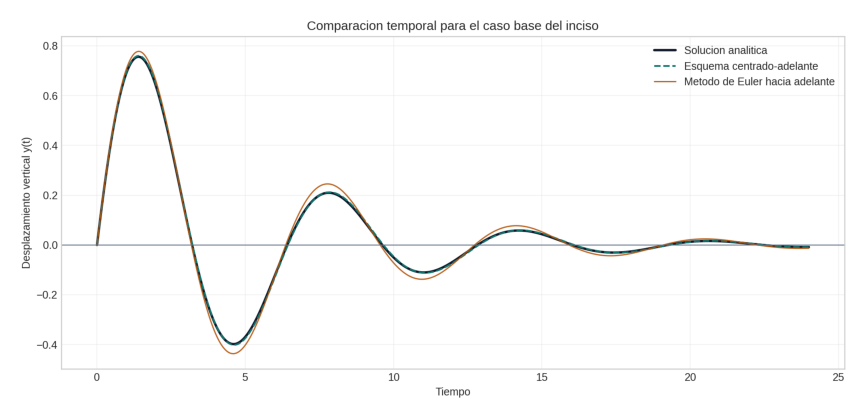

Metricas del caso principal:


regimen                         subamortiguado
omega_0                                1.00000
alpha                                  0.20000
desplazamiento_inicial                 0.00000
desplazamiento_final_exacto           -0.00839
desplazamiento_final_esquema          -0.00868
desplazamiento_final_euler            -0.01304
rmse_esquema                           0.00366
rmse_euler                             0.01773
dtype: object

In [2]:
image_path = OUTPUT_DIR / 'globo_desplazamiento_comparacion.png'
img = plt.imread(image_path)
plt.figure(figsize=(11, 5.2))
plt.imshow(img)
plt.axis('off')
plt.show()

print('Metricas del caso principal:')
pd.Series(summary['caso_principal'])

## Retrato de fase

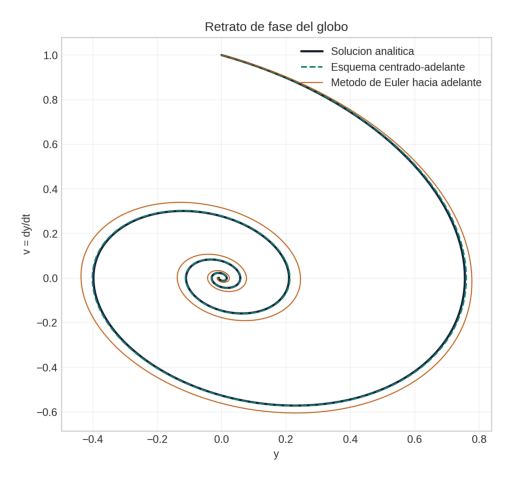

In [3]:
image_path = OUTPUT_DIR / 'globo_retrato_fase.png'
img = plt.imread(image_path)
plt.figure(figsize=(6.4, 6.0))
plt.imshow(img)
plt.axis('off')
plt.show()

## Regimenes de amortiguamiento

Se comparan tres escenarios con los mismos `m`, `gamma`, `y(0)=0` y `v0`, pero con `beta` diferente para resaltar las diferencias entre respuesta oscilatoria, critica y sobreamortiguada.

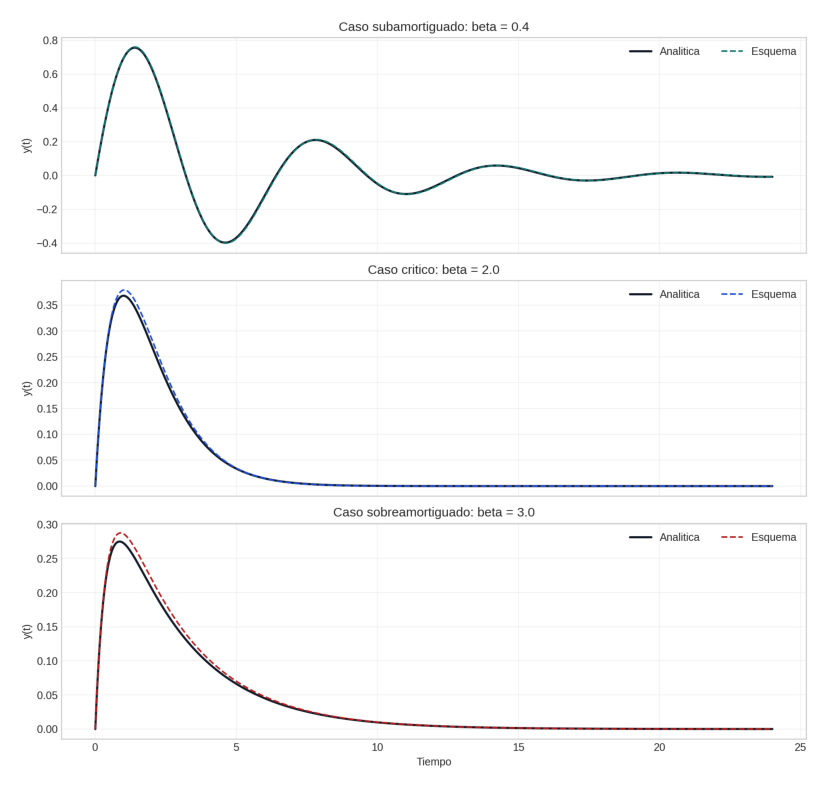

In [4]:
image_path = OUTPUT_DIR / 'globo_regimenes_amortiguamiento.png'
img = plt.imread(image_path)
plt.figure(figsize=(10.5, 10.0))
plt.imshow(img)
plt.axis('off')
plt.show()

## Sensibilidad al paso temporal

Este barrido permite evaluar cuando la discretizacion sigue siendo confiable y cuando el metodo de Euler hacia adelante comienza a degradarse con mayor rapidez.

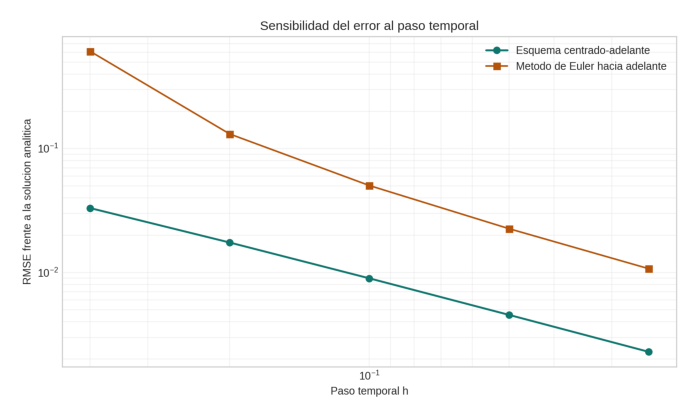

,dt,rmse_esquema,rmse_euler,max_error_esquema,max_error_euler
0,0.40000,0.03315,0.61011,0.07045,0.99784
1,0.20000,0.01748,0.13128,0.03801,0.25538
2,0.10000,0.00899,0.05040,0.01963,0.10496
3,0.05000,0.00456,0.02262,0.00998,0.04940
4,0.02500,0.00230,0.01076,0.00503,0.02398


In [5]:
image_path = OUTPUT_DIR / 'globo_convergencia_dt.png'
img = plt.imread(image_path)
plt.figure(figsize=(8.8, 5.2))
plt.imshow(img)
plt.axis('off')
plt.show()

study_df

## Energia mecanica

Aunque el modelo no incluye una energia conservada por la presencia de amortiguamiento, si debe mostrar una tendencia decreciente compatible con la disipacion por resistencia del aire.

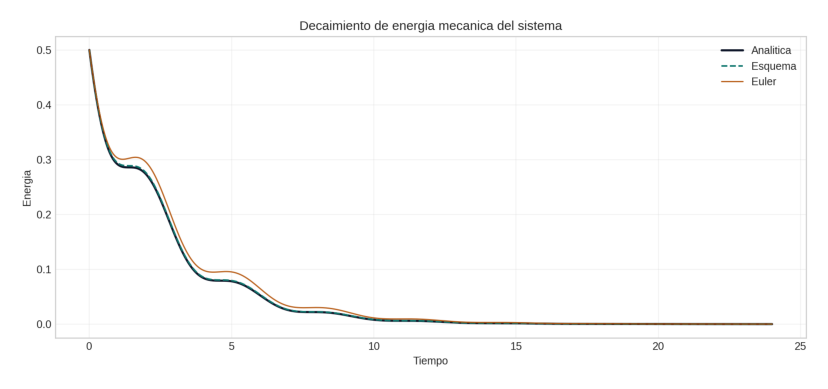

In [6]:
image_path = OUTPUT_DIR / 'globo_energia.png'
img = plt.imread(image_path)
plt.figure(figsize=(10.5, 4.8))
plt.imshow(img)
plt.axis('off')
plt.show()

## Analisis de sensibilidad

En esta seccion se separa la sensibilidad del modelo fisico de la sensibilidad de la solucion numerica. El objetivo es distinguir entre cambios reales en la dinamica del globo y cambios introducidos por la discretizacion.

### Sensibilidad fisica a beta

Se varia `beta` para observar la transicion entre regimenes y medir su efecto en la amplitud, el numero de cruces por cero y el tiempo de estabilizacion.

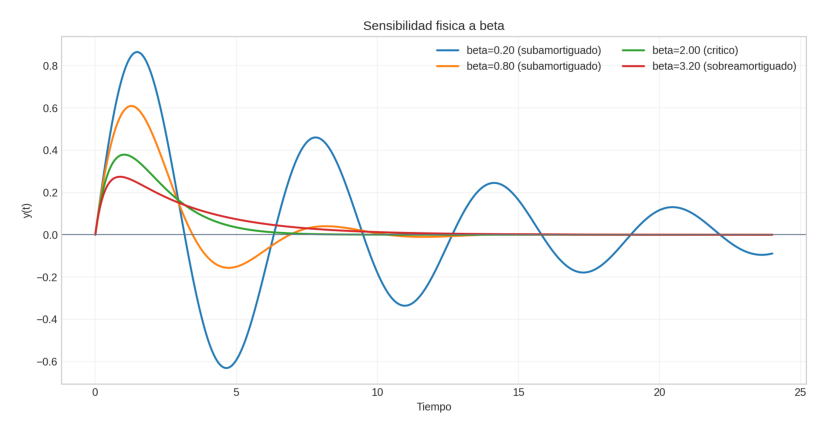

,beta,regimen,desplazamiento_maximo,periodo_aparente,cruces_cero,tiempo_estabilizacion_5pct
0,0.20000,subamortiguado,0.86472,6.32000,7,24.00000
1,0.80000,subamortiguado,0.60956,6.89600,6,9.00000
2,2.00000,critico,0.37900,NaN,1,5.72000
3,3.20000,sobreamortiguado,0.27433,NaN,0,9.76000


In [7]:
image_path = OUTPUT_DIR / 'globo_sensibilidad_beta.png'
img = plt.imread(image_path)
plt.figure(figsize=(10.5, 5.4))
plt.imshow(img)
plt.axis('off')
plt.show()

beta_summary_df

### Sensibilidad fisica a gamma y m

Como la frecuencia natural depende de `sqrt(gamma/m)`, se evalua una malla simple de valores para ver como cambia el periodo aparente del sistema.

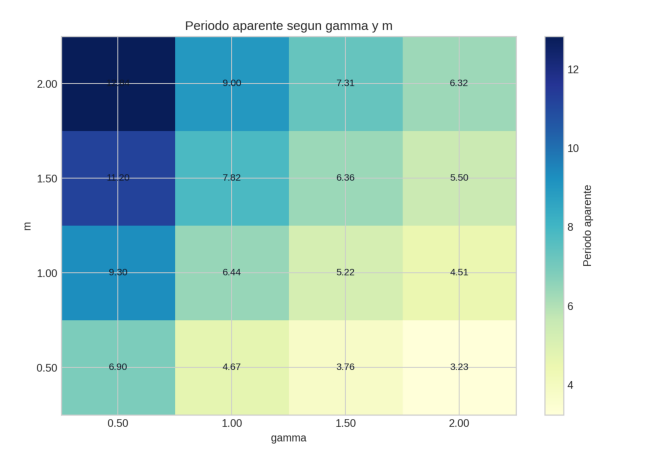

,m,gamma,periodo_aparente,desplazamiento_maximo
0,0.50000,0.50000,6.89600,0.60956
1,0.50000,1.00000,4.66667,0.48930
2,0.50000,1.50000,3.76000,0.42464
3,0.50000,2.00000,3.23077,0.38181
4,1.00000,0.50000,9.30000,0.97347
5,1.00000,1.00000,6.44000,0.75997
6,1.00000,1.50000,5.22000,0.65011
7,1.00000,2.00000,4.50667,0.57932


In [8]:
image_path = OUTPUT_DIR / 'globo_sensibilidad_gamma_m.png'
img = plt.imread(image_path)
plt.figure(figsize=(8.2, 5.8))
plt.imshow(img)
plt.axis('off')
plt.show()

gamma_mass_df.head(8)

### Sensibilidad a las condiciones iniciales

Se analiza por separado la perturbacion de `v_0` con `y(0)=0` y la perturbacion de `y(0)` con `v_0` fijo, para ver su efecto en amplitud, fase y energia inicial.

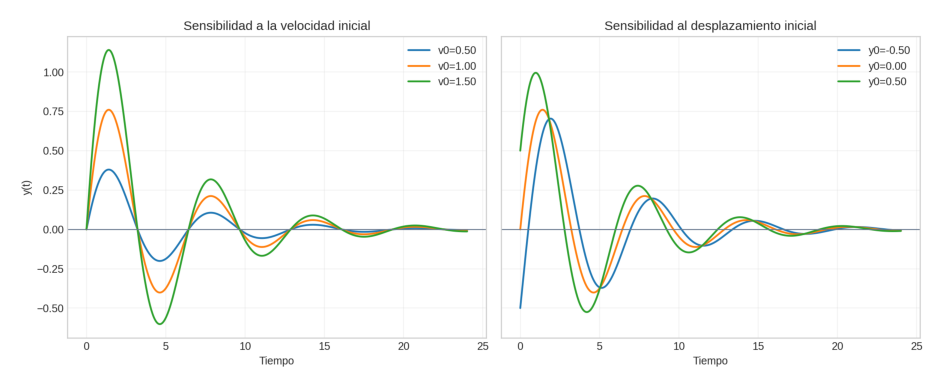

,tipo,valor,regimen,desplazamiento_maximo,periodo_aparente,cruces_cero,tiempo_estabilizacion_5pct
0,variacion_v0,0.50000,subamortiguado,0.37999,6.44000,7,15.24000
1,variacion_v0,1.00000,subamortiguado,0.75997,6.44000,7,15.24000
2,variacion_v0,1.50000,subamortiguado,1.13996,6.44000,7,15.24000
3,variacion_y0,-0.50000,subamortiguado,0.70393,6.43429,8,15.72000
4,variacion_y0,0.00000,subamortiguado,0.75997,6.44000,7,15.24000
5,variacion_y0,0.50000,subamortiguado,0.99479,6.44000,7,14.80000


In [9]:
image_path = OUTPUT_DIR / 'globo_sensibilidad_condiciones_iniciales.png'
img = plt.imread(image_path)
plt.figure(figsize=(12.0, 4.8))
plt.imshow(img)
plt.axis('off')
plt.show()

initial_summary_df

### Sensibilidad de convergencia

Se cuantifican las normas `E_2` y `E_infty` para verificar que el error disminuya de manera sistematica al refinar el paso temporal.

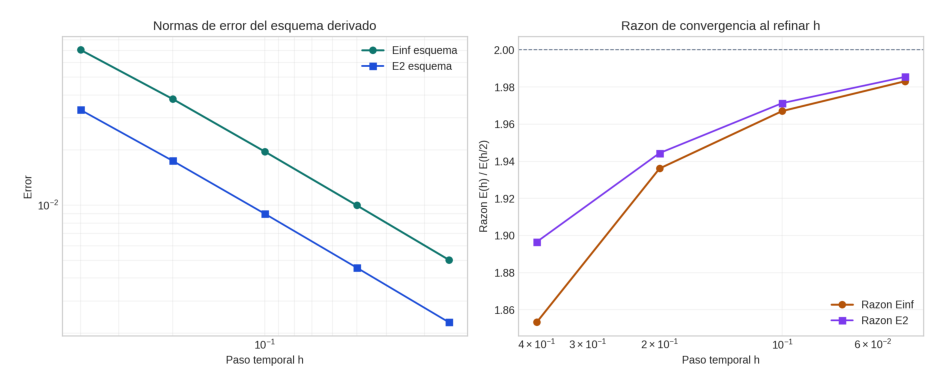

,dt,e2_esquema,einf_esquema,ratio_einf,ratio_e2
0,0.40000,0.03315,0.07045,1.85332,1.89658
1,0.20000,0.01748,0.03801,1.93609,1.94439
2,0.10000,0.00899,0.01963,1.96704,1.97132
3,0.05000,0.00456,0.00998,1.98310,1.98545
4,0.02500,0.00230,0.00503,NaN,NaN


In [10]:
image_path = OUTPUT_DIR / 'globo_convergencia_normas.png'
img = plt.imread(image_path)
plt.figure(figsize=(12.0, 4.8))
plt.imshow(img)
plt.axis('off')
plt.show()

norms_df

### Sensibilidad de estabilidad numerica

Se incrementa `h` para identificar desde cuando aparecen respuestas numericas no fisicas, como crecimientos exagerados o cambios artificiales del patron oscilatorio.

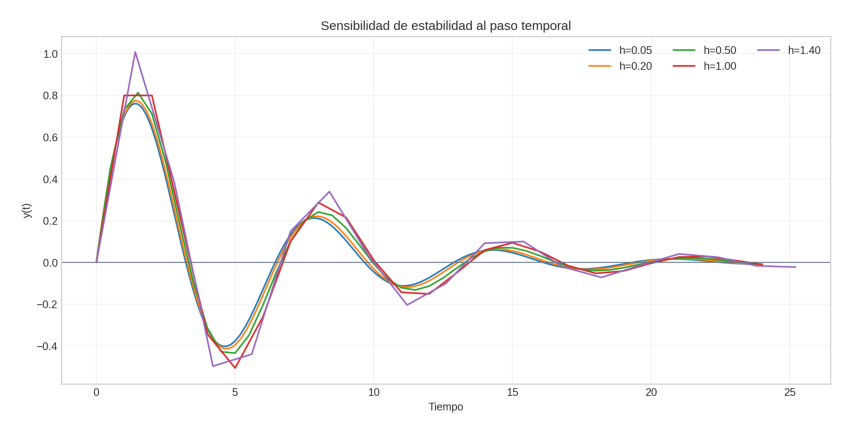

,dt,max_abs_y,cruces_cero,estable_aprox
0,0.05000,0.76095,7,True
1,0.20000,0.77642,7,True
2,0.50000,0.81328,7,True
3,1.00000,0.80000,7,True
4,1.40000,1.00800,7,True


In [11]:
image_path = OUTPUT_DIR / 'globo_estabilidad_dt.png'
img = plt.imread(image_path)
plt.figure(figsize=(10.8, 5.4))
plt.imshow(img)
plt.axis('off')
plt.show()

stability_df

### Sensibilidad al metodo de arranque

El esquema es de dos pasos, asi que el modo de construir `y_1` influye en el error global. Se comparan los arranques por Euler, Taylor de segundo orden y valor exacto en `t = h`.

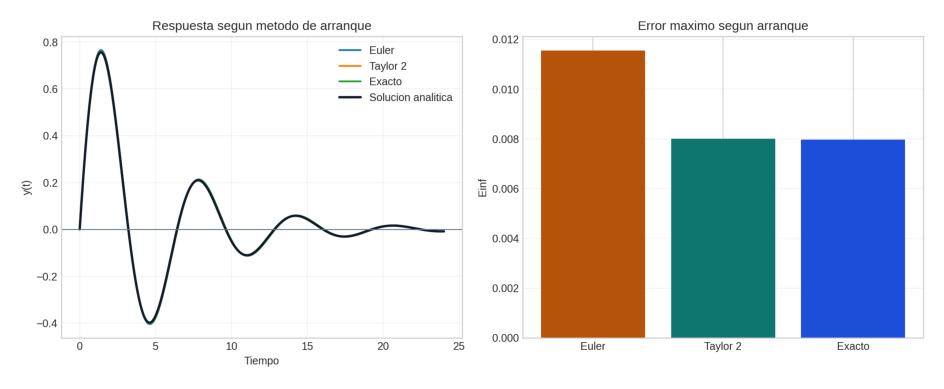

,metodo_arranque,e2,einf,error_final
0,Euler,0.00487,0.01155,-0.00036
1,Taylor 2,0.00366,0.00801,-0.00029
2,Exacto,0.00363,0.00797,-0.00029


In [12]:
image_path = OUTPUT_DIR / 'globo_arranque_comparacion.png'
img = plt.imread(image_path)
plt.figure(figsize=(12.0, 4.8))
plt.imshow(img)
plt.axis('off')
plt.show()

start_summary_df

## Discusion breve

- El esquema derivado sigue de cerca la solucion analitica en los tres regimens.
- El metodo de Euler hacia adelante puede capturar la tendencia cualitativa, pero acumula mas error de fase y amplitud.
- Al aumentar `h`, ambos metodos empeoran, aunque el esquema derivado se mantiene mas preciso para el mismo paso.
- La energia decrece con el tiempo, como exige la interpretacion fisica del amortiguamiento.
- La sensibilidad muestra que `beta` controla la transicion de regimen, mientras `gamma/m` controla la escala temporal de la oscilacion.
- El arranque por Taylor o por valor exacto reduce de forma visible el error frente a un arranque por Euler.
- En el caso subamortiguado, la oscilacion del globo es visible y su amplitud se atenúa progresivamente.

## Animacion final del globo

La siguiente animacion muestra la posicion vertical del globo y la evolucion temporal de `y(t)` usando la discretizacion derivada en el inciso.

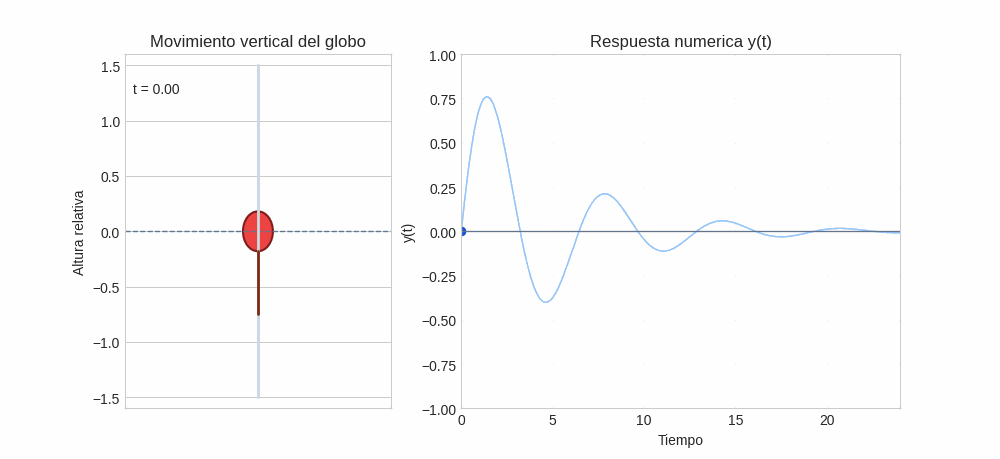

In [13]:
display(Image(filename=str(OUTPUT_DIR / 'globo_oscilacion.gif')))